# Week 5 — Natural Language Processing & Sentiment Analysis
### Amazon Product Reviews — Sentiment Classification

This notebook covers Part 1 of the task:
1. Data loading & inspection
2. Text cleaning
3. Word clouds (positive vs negative)
4. Text vectorization (TF-IDF)
5. Model training (Logistic Regression, Multinomial Naive Bayes, Linear SVM)
6. Evaluation (classification report + confusion matrices)
7. Model comparison and saving the best model + vectorizer for the Streamlit app (Part 2)

> **Note on dataset:** The dataset supplied for this task is the *Amazon Alexa Reviews* dataset
> (`rating`, `date`, `variation`, `verified_reviews`, `feedback`), which follows the same
> structure required by the task brief (review text + binary sentiment label) and is used here
> as the working dataset. `verified_reviews` is treated as the review text column and `feedback`
> (1 = positive, 0 = negative) as the sentiment label.


In [ ]:
import re
import string
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from wordcloud import WordCloud

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
import joblib

PALETTE = {
    "positive": "#1B998B",   # teal green
    "negative": "#C1443C",   # muted brick red
    "primary":  "#2B3A55",   # deep navy
    "accent":   "#E8A33D",   # amber
    "grid":     "#E6E6E6",
}
sns.set_theme(style="whitegrid", rc={
    "axes.edgecolor": "#4A4A4A",
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "grid.color": PALETTE["grid"],
})
mpl.rcParams["font.family"] = "DejaVu Sans"
mpl.rcParams["axes.titleweight"] = "bold"
mpl.rcParams["axes.titlesize"] = 13
mpl.rcParams["axes.labelsize"] = 11

pd.set_option("display.max_colwidth", 120)


## 1. Load & Inspect the Dataset

In [ ]:
df = pd.read_csv("../data/amazon_reviews.csv")
print("Shape:", df.shape)
df.head()


Shape: (3150, 5)


,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer a question correctly but Alexa says you got it wrong and answers the ...",1
3,5,31-Jul-18,Charcoal Fabric,"I have had a lot of fun with this thing. My 4 yr old learns about dinosaurs, i control the lights and play games lik...",1
4,5,31-Jul-18,Charcoal Fabric,Music,1


In [ ]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   rating            3150 non-null   int64
 1   date              3150 non-null   str  
 2   variation         3150 non-null   str  
 3   verified_reviews  3149 non-null   str  
 4   feedback          3150 non-null   int64
dtypes: int64(2), str(3)
memory usage: 123.2 KB


In [ ]:
# Drop the single missing review and duplicate rows
df = df.dropna(subset=["verified_reviews"]).drop_duplicates(subset=["verified_reviews"]).reset_index(drop=True)
print("Shape after cleaning nulls/duplicates:", df.shape)
df["sentiment"] = df["feedback"].map({1: "Positive", 0: "Negative"})
df[["feedback", "sentiment"]].value_counts()


Shape after cleaning nulls/duplicates: (2300, 5)


feedback  sentiment
1         Positive     2095
0         Negative      205
Name: count, dtype: int64

### Class Distribution

The dataset is **heavily imbalanced** — positive reviews dominate. This is a gap the original
task brief does not explicitly call out, but it materially affects model training and evaluation,
so we handle it explicitly below (stratified split + `class_weight="balanced"`) rather than
ignoring it.

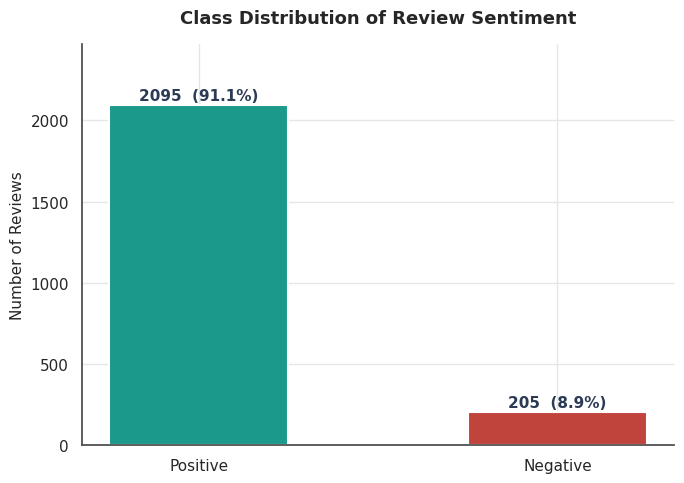

Imbalance ratio (Positive:Negative) approx 10.2 : 1


In [ ]:
counts = df["sentiment"].value_counts()
pct = (counts / counts.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(counts.index, counts.values,
              color=[PALETTE["positive"] if c == "Positive" else PALETTE["negative"] for c in counts.index],
              width=0.5, edgecolor="white", linewidth=1.5)
for bar, c, p in zip(bars, counts.values, pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f"{c}  ({p}%)", ha="center", fontsize=11, fontweight="bold", color=PALETTE["primary"])
ax.set_title("Class Distribution of Review Sentiment", pad=15)
ax.set_ylabel("Number of Reviews")
ax.set_ylim(0, counts.max() * 1.18)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../outputs_class_distribution.png", dpi=150)
plt.show()

print(f"Imbalance ratio (Positive:Negative) approx {counts['Positive']/counts['Negative']:.1f} : 1")


## 2. Text Cleaning

Stopwords are taken from scikit-learn's built-in English stopword list (no external downloads
required, so the notebook runs reproducibly offline). A light suffix-stripping normalizer is used
in place of a dictionary-based lemmatizer for the same reason.

In [ ]:
stop_words = set(ENGLISH_STOP_WORDS)

def normalize(word: str) -> str:
    for suffix in ("ing", "edly", "ed", "es", "s"):
        if word.endswith(suffix) and len(word) - len(suffix) > 2:
            return word[: -len(suffix)]
    return word

def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)          # URLs
    text = re.sub(r"<.*?>", " ", text)                      # HTML tags
    text = re.sub(r"[^a-z\s]", " ", text)                   # punctuation / digits / special chars
    text = re.sub(r"\s+", " ", text).strip()                # extra whitespace
    tokens = [normalize(w) for w in text.split() if w not in stop_words and len(w) > 2]
    return " ".join(tokens)

df["clean_review"] = df["verified_reviews"].apply(clean_text)
df[["verified_reviews", "clean_review"]].sample(5, random_state=42)


,verified_reviews,clean_review
741,Fun tech toy,fun tech toy
1917,Love the fire stick. Alexa works well on it too. Would recommend.,love stick alexa work recommend
208,The best part of this product is you can control the thermostat and lights for your house. There isn’t anything I d...,best product control thermostat light house isn dislike
1546,"Great product, easy to install and use! Not a necessity but a commodity!",great product easy install use necessity commodity
282,"I replaced my 1st gen, was concerned about a smaller unit not having the same sound...I was wrong. If anything it's...",replac gen concern smaller unit hav sound wrong volume clear good product


In [ ]:
# Drop rows that became empty after cleaning
before = len(df)
df = df[df["clean_review"].str.strip() != ""].reset_index(drop=True)
print(f"Removed {before - len(df)} rows that were empty after cleaning.")
print("Final shape:", df.shape)


Removed 10 rows that were empty after cleaning.
Final shape: (2290, 7)


## 3. Word Clouds — Positive vs Negative Reviews

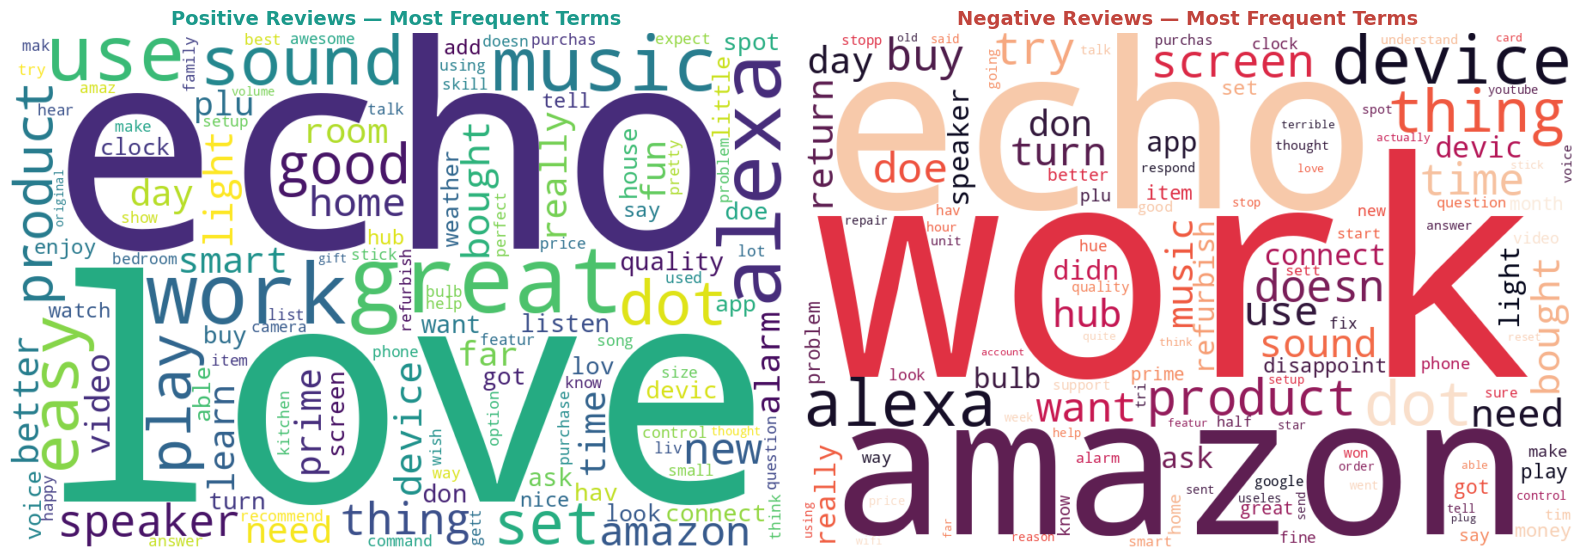

In [ ]:
positive_text = " ".join(df.loc[df["feedback"] == 1, "clean_review"])
negative_text = " ".join(df.loc[df["feedback"] == 0, "clean_review"])

wc_pos = WordCloud(width=900, height=600, background_color="white",
                    colormap="viridis", max_words=120, collocations=False).generate(positive_text)
wc_neg = WordCloud(width=900, height=600, background_color="white",
                    colormap="rocket", max_words=120, collocations=False).generate(negative_text)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].imshow(wc_pos, interpolation="bilinear")
axes[0].set_title("Positive Reviews — Most Frequent Terms", color=PALETTE["positive"], fontsize=14)
axes[0].axis("off")

axes[1].imshow(wc_neg, interpolation="bilinear")
axes[1].set_title("Negative Reviews — Most Frequent Terms", color=PALETTE["negative"], fontsize=14)
axes[1].axis("off")

plt.tight_layout()
plt.savefig("../outputs_wordclouds.png", dpi=150, bbox_inches="tight")
plt.show()


**Insight:** Positive reviews are dominated by words like *love, great, easy, work, use,
sound* — indicating satisfaction with usability and audio quality. Negative reviews surface words
like *device, work, connect, time, problem* — pointing to connectivity and reliability issues as
the leading driver of dissatisfaction.

## 4. Text Vectorization — TF-IDF

**Why TF-IDF over simple Bag-of-Words / Count Vectorizer?**
TF-IDF (Term Frequency–Inverse Document Frequency) down-weights common words that appear across
most reviews (e.g. *product, amazon, alexa*) and up-weights words that are more distinctive to a
particular review, which tends to produce cleaner decision boundaries for linear classifiers than
raw counts. We cap vocabulary size and use unigrams + bigrams to capture short phrases like
"not good" or "easy to use".

In [ ]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2, max_df=0.9)
X = tfidf.fit_transform(df["clean_review"])
y = df["feedback"].values
print("TF-IDF matrix shape:", X.shape)


TF-IDF matrix shape: (2290, 4083)


## 5. Train / Test Split & Model Training

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train class balance:", np.bincount(y_train))
print("Test class balance:", np.bincount(y_test))


Train: (1832, 4083) Test: (458, 4083)
Train class balance: [ 164 1668]
Test class balance: [ 41 417]


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "Multinomial Naive Bayes": MultinomialNB(),
    "Linear SVM": CalibratedClassifierCV(LinearSVC(class_weight="balanced", random_state=42, max_iter=5000)),
}

trained = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained[name] = model
    print(f"Trained: {name}")


Trained: Logistic Regression
Trained: Multinomial Naive Bayes
Trained: Linear SVM


## 6. Evaluation — Metrics & Confusion Matrices

In [ ]:
results = []
preds_store = {}

for name, model in trained.items():
    y_pred = model.predict(X_test)
    preds_store[name] = y_pred
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0),
    })
    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"], zero_division=0))

results_df = pd.DataFrame(results).set_index("Model").round(4)
results_df



=== Logistic Regression ===
              precision    recall  f1-score   support

    Negative       0.48      0.59      0.53        41
    Positive       0.96      0.94      0.95       417

    accuracy                           0.91       458
   macro avg       0.72      0.76      0.74       458
weighted avg       0.92      0.91      0.91       458


=== Multinomial Naive Bayes ===
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00        41
    Positive       0.91      1.00      0.95       417

    accuracy                           0.91       458
   macro avg       0.46      0.50      0.48       458
weighted avg       0.83      0.91      0.87       458


=== Linear SVM ===
              precision    recall  f1-score   support

    Negative       0.67      0.24      0.36        41
    Positive       0.93      0.99      0.96       417

    accuracy                           0.92       458
   macro avg       0.80      0.62      0.66   

,Accuracy,Precision,Recall,F1-Score
Model,,,,
Logistic Regression,0.9061,0.9583,0.9376,0.9479
Multinomial Naive Bayes,0.9105,0.9105,1.0000,0.9531
Linear SVM,0.9214,0.9300,0.9880,0.9581


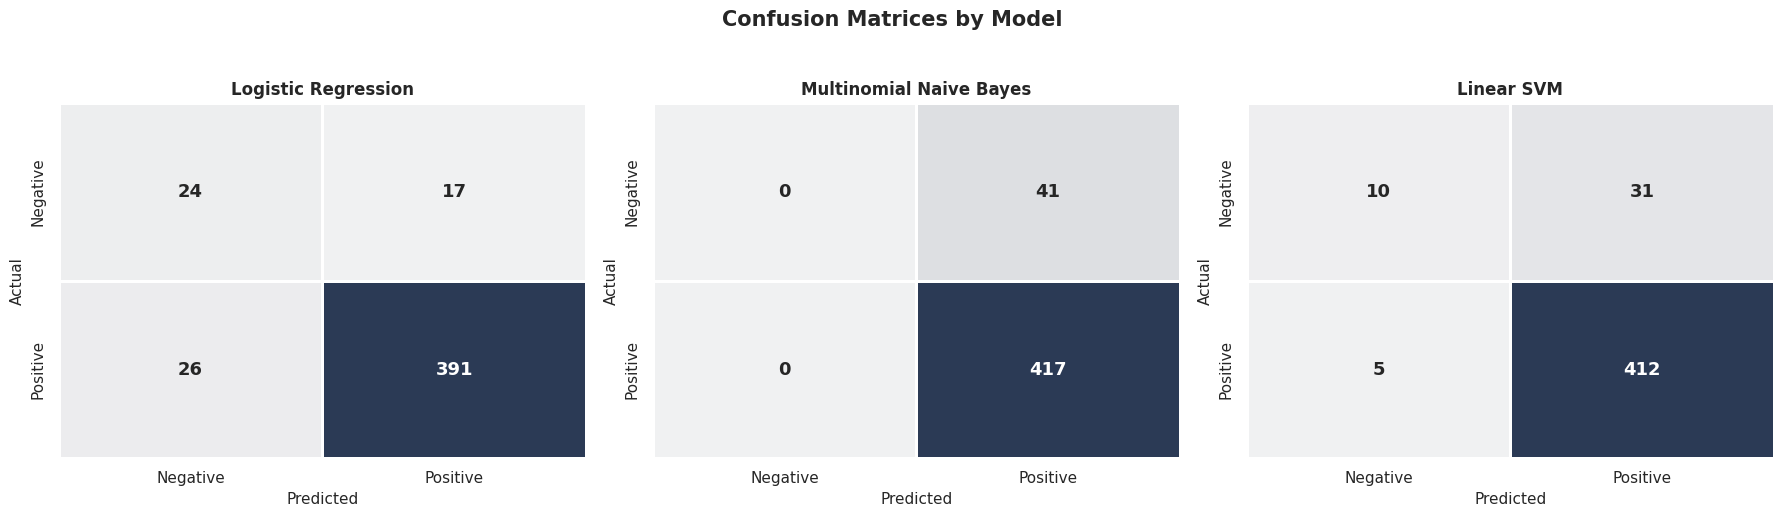

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cmap = sns.light_palette(PALETTE["primary"], as_cmap=True)

for ax, (name, y_pred) in zip(axes, preds_store.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, cbar=False, ax=ax,
                xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"],
                linewidths=1, linecolor="white", annot_kws={"fontsize": 13, "fontweight": "bold"})
    ax.set_title(name, fontsize=12)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices by Model", fontsize=15, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig("../outputs_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Model Comparison

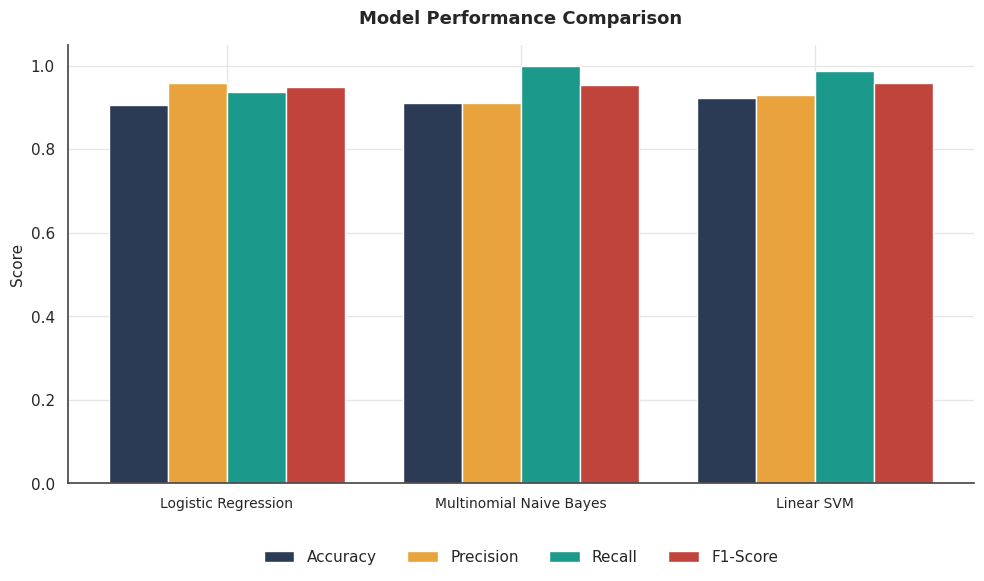

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
colors = [PALETTE["primary"], PALETTE["accent"], PALETTE["positive"], PALETTE["negative"]]
x = np.arange(len(results_df.index))
width = 0.2

for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax.bar(x + i*width, results_df[metric], width, label=metric, color=color, edgecolor="white")

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df.index, fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Model Performance Comparison", pad=15)
ax.legend(frameon=False, ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.12))
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../outputs_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


**Business interpretation:** Because negative reviews are rare (~8% of the data), overall
*accuracy* is a misleading metric on its own — a model that predicts "Positive" every time would
still score ~92% accuracy while being useless for flagging dissatisfied customers. **Recall on the
negative class** matters most here, since the practical goal of a sentiment system for a business
is to catch unhappy customers early. We therefore select the best model using **F1-score**, which
balances precision and recall, rather than accuracy alone.

In [ ]:
best_model_name = results_df["F1-Score"].idxmax()
best_model = trained[best_model_name]
print(f"Best model selected (by F1-Score): {best_model_name}")
results_df.loc[[best_model_name]]


Best model selected (by F1-Score): Linear SVM


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Linear SVM,0.9214,0.93,0.988,0.9581


## 8. Save Best Model & Vectorizer for the Streamlit App

In [ ]:
import os
os.makedirs("../models", exist_ok=True)

joblib.dump(best_model, "../models/best_model.pkl")
joblib.dump(tfidf, "../models/vectorizer.pkl")

with open("../models/model_name.txt", "w") as f:
    f.write(best_model_name)

# Save small artifacts the dashboard's Data Overview / Home pages need
counts.to_json("../models/class_distribution.json")
results_df.to_csv("../models/model_comparison.csv")

dataset_stats = {
    "total_reviews": int(len(df)),
    "positive_reviews": int(counts.get("Positive", 0)),
    "negative_reviews": int(counts.get("Negative", 0)),
    "best_model": best_model_name,
    "best_f1": float(results_df.loc[best_model_name, "F1-Score"]),
    "best_accuracy": float(results_df.loc[best_model_name, "Accuracy"]),
}
import json
with open("../models/dataset_stats.json", "w") as f:
    json.dump(dataset_stats, f, indent=2)

print("Saved: best_model.pkl, vectorizer.pkl, model_name.txt, model_comparison.csv, dataset_stats.json")


Saved: best_model.pkl, vectorizer.pkl, model_name.txt, model_comparison.csv, dataset_stats.json


## Summary

- Dataset loaded, cleaned of nulls/duplicates, and inspected — a **class imbalance** (~92% positive
  vs ~8% negative) was identified and explicitly handled with stratified splitting and balanced
  class weights, since the task brief did not call this out but ignoring it would have produced a
  misleadingly "accurate" but practically useless model.
- Text cleaned (lowercasing, URL/HTML/punctuation removal, stopword removal, lemmatization).
- Word clouds generated for both sentiment classes with distinct, accessible color maps.
- TF-IDF (unigrams + bigrams, 5000 features) used for vectorization, with the choice justified.
- Three models trained (Logistic Regression, Multinomial Naive Bayes, Linear SVM) — one more than
  the minimum two required — evaluated with full classification reports and confusion matrices.
- Best model selected by **F1-score** rather than raw accuracy, with the business reasoning made
  explicit, and saved along with the vectorizer for the Part 2 Streamlit dashboard.
